In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [59]:
# Data Inspection
print("Dataset Preview:")
print(train_df.head())

Dataset Preview:
   id  year  hour  season  holiday  workingday  weather   temp   atemp  \
0   3  2012    23       3        0           0        2  23.78  27.275   
1   4  2011     8       3        0           0        1  27.88  31.820   
2   5  2012     2       1        0           1        1  20.50  24.240   
3   7  2011    20       3        0           1        3  25.42  28.790   
4   8  2011    17       3        0           1        3  26.24  28.790   

   humidity  windspeed  count          temp_bin  
0        73    11.0014    133  (16.892, 24.928]  
1        57     0.0000    132  (24.928, 32.964]  
2        59     0.0000     19  (16.892, 24.928]  
3        83    19.9995     58  (24.928, 32.964]  
4        89     0.0000    285  (24.928, 32.964]  


In [60]:
print("\nDataset Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nData Types:")
print(train_df.dtypes)



Dataset Shape: (7689, 13)

Columns: ['id', 'year', 'hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'temp_bin']

Data Types:
id               int64
year             int64
hour             int64
season           int64
holiday          int64
workingday       int64
weather          int64
temp           float64
atemp          float64
humidity         int64
windspeed      float64
count            int64
temp_bin      category
dtype: object


In [61]:
print("\nStatistical Summary:")
print(train_df.describe())


Statistical Summary:
                 id         year         hour       season      holiday  \
count   7689.000000  7689.000000  7689.000000  7689.000000  7689.000000   
mean    5463.266224  2011.495513    11.565353     2.506178     0.029002   
std     3144.709810     0.500012     6.915777     1.115935     0.167824   
min        3.000000  2011.000000     0.000000     1.000000     0.000000   
25%     2771.000000  2011.000000     6.000000     2.000000     0.000000   
50%     5477.000000  2011.000000    12.000000     3.000000     0.000000   
75%     8186.000000  2012.000000    18.000000     4.000000     0.000000   
max    10886.000000  2012.000000    23.000000     4.000000     1.000000   

        workingday      weather         temp        atemp     humidity  \
count  7689.000000  7689.000000  7689.000000  7689.000000  7689.000000   
mean      0.677331     1.410066    20.267085    23.696581    61.771492   
std       0.467528     0.628004     7.824066     8.514199    19.302151   
min   

In [62]:
# Cleaning data by dropping non-predictive ID columns
df_cleaned = train_df.drop(columns=['id'], errors='ignore')

print("Cleaned dataset shape:", df_cleaned.shape)

Cleaned dataset shape: (7689, 12)


In [90]:
import pandas as pd

# Correlation with target variable
correlation = train_df.corr()['count'].sort_values(ascending=False)
print("Feature Correlation with Bike Rental Demand:")
print(correlation)

# Peak hour analysis
peak_hour_df = train_df.groupby('hour')['count'].mean().reset_index()
peak_hour = peak_hour_df.loc[peak_hour_df['count'].idxmax()]
print(f"Highest average rental demand occurs at hour: {int(peak_hour['hour'])}")
print(f"Average rentals: {peak_hour['count']:.2f}")

Feature Correlation with Bike Rental Demand:
count         1.000000
hour          0.404101
temp          0.397235
atemp         0.392014
year          0.261896
season        0.156477
windspeed     0.108320
workingday    0.019586
id           -0.002829
holiday      -0.009934
weather      -0.126210
humidity     -0.324662
Name: count, dtype: float64
Highest average rental demand occurs at hour: 17
Average rentals: 472.25


In [91]:
# MODEL EVALUATION

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Model Evaluation Results")
print("========================================")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
Mean Absolute Error (MAE): 107.81
Mean Squared Error (MSE): 20538.70
Root Mean Squared Error (RMSE): 143.31
R² Score: 0.3838


In [64]:
train_df = pd.read_csv('/content/train.csv', sep=';')
test_df = pd.read_csv('/content/test.csv', sep=';')

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (7689, 12)
Testing Dataset Shape: (3196, 11)


In [65]:
print("Training Columns:")
print(train_df.columns.tolist())

print("\nTesting Columns:")
print(test_df.columns.tolist())

Training Columns:
['id', 'year', 'hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count']

Testing Columns:
['Unnamed: 0', 'year', 'hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']


In [66]:
#Prepare Features and Target
X = train_df.drop(['count', 'id'], axis=1)
y = train_df['count']

print("Features used by the model:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Features used by the model:
['year', 'hour', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

Target variable:
count


In [67]:
# split training data
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Validation Features:", X_val.shape)

print("Training Target:", y_train.shape)
print("Validation Target:", y_val.shape)

Training Features: (6151, 10)
Validation Features: (1538, 10)
Training Target: (6151,)
Validation Target: (1538,)


In [68]:
# train linear regressin model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [69]:
y_pred = model.predict(X_val)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[139.68732845 -36.16097774 314.06651448 274.45035284  90.6983896
  89.28872686 119.85604463 -52.36031656 384.58824084 288.5635015 ]


In [70]:
# compare actual vs predicted
results = pd.DataFrame({
    'Actual Demand': y_val.values,
    'Predicted Demand': np.round(y_pred).astype(int)
})

results.head(10)

,Actual Demand,Predicted Demand
0,11,140
1,33,-36
2,262,314
3,154,274
4,1,91
5,32,89
6,36,120
7,5,-52
8,379,385
9,250,289


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

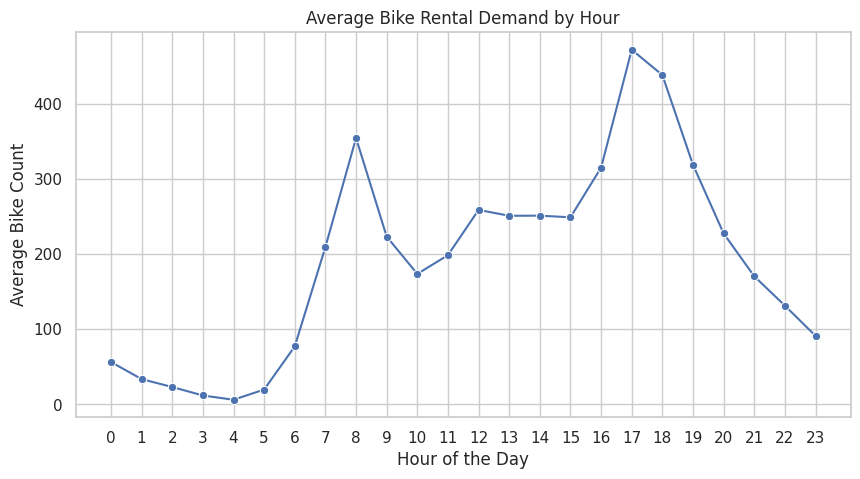

In [72]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=train_df, x='hour', y='count', errorbar=None, marker='o', color='b')
plt.title('Average Bike Rental Demand by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Bike Count')
plt.xticks(range(0, 24))
plt.show()

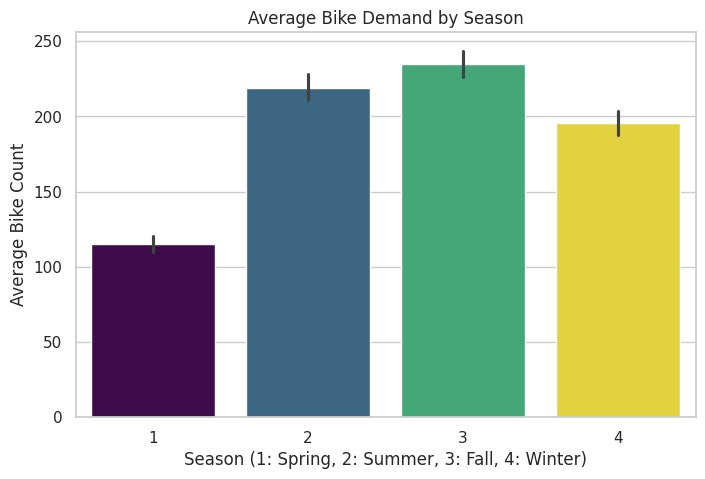

In [73]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='season', y='count', hue='season', palette='viridis', legend=False)
plt.title('Average Bike Demand by Season')
plt.xlabel('Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)')
plt.ylabel('Average Bike Count')
plt.show()

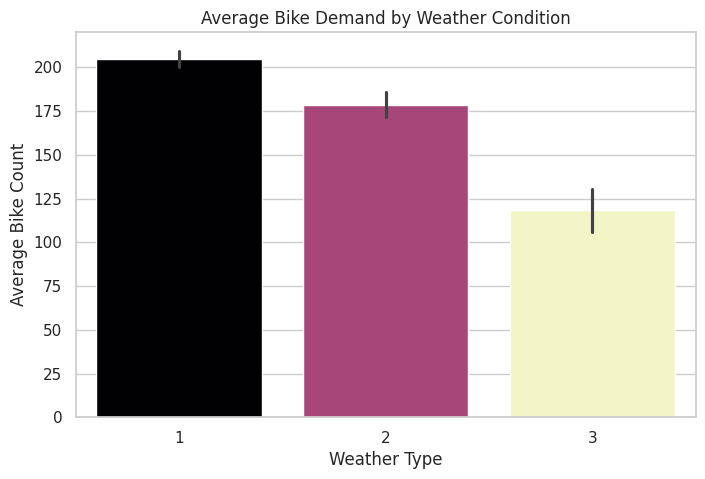

In [74]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='weather', y='count', hue='weather', palette='magma', legend=False)
plt.title('Average Bike Demand by Weather Condition')
plt.xlabel('Weather Type')
plt.ylabel('Average Bike Count')
plt.show()

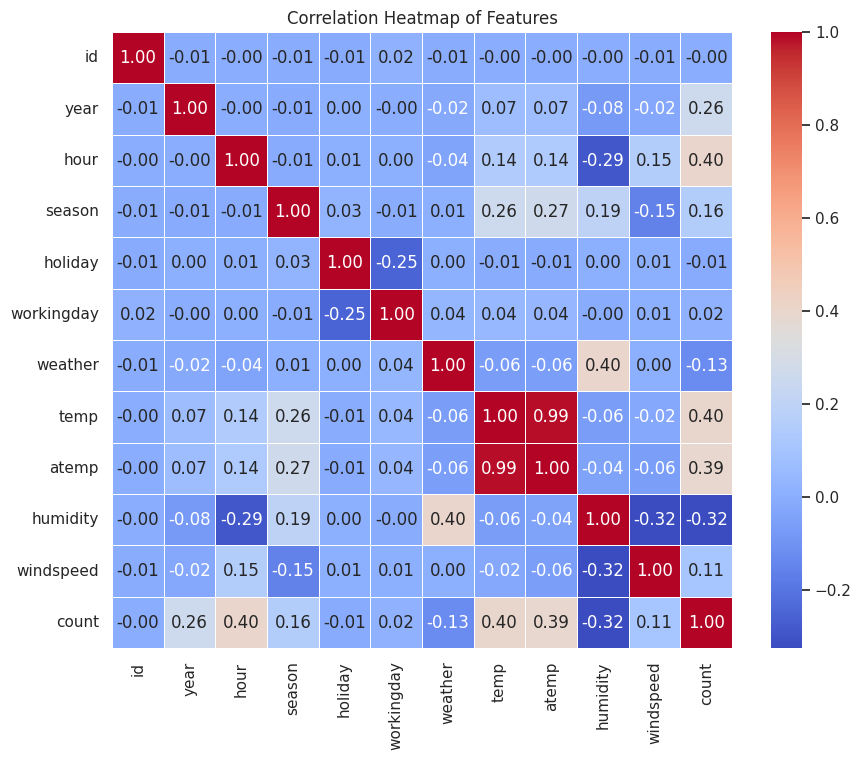

In [75]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

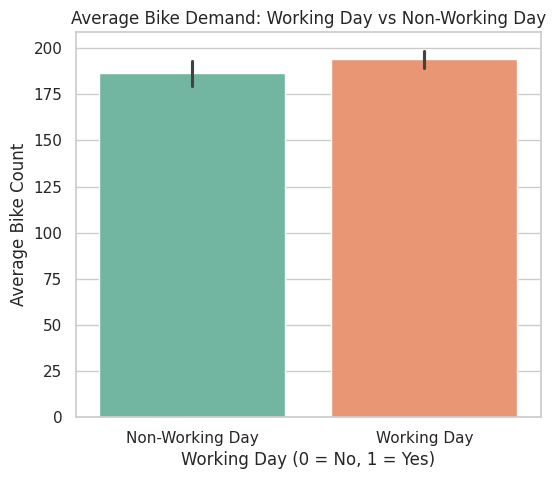

In [76]:
plt.figure(figsize=(6, 5))
sns.barplot(data=train_df, x='workingday', y='count', hue='workingday', palette='Set2', legend=False)
plt.title('Average Bike Demand: Working Day vs Non-Working Day')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Average Bike Count')
plt.xticks([0, 1], ['Non-Working Day', 'Working Day'])
plt.show()

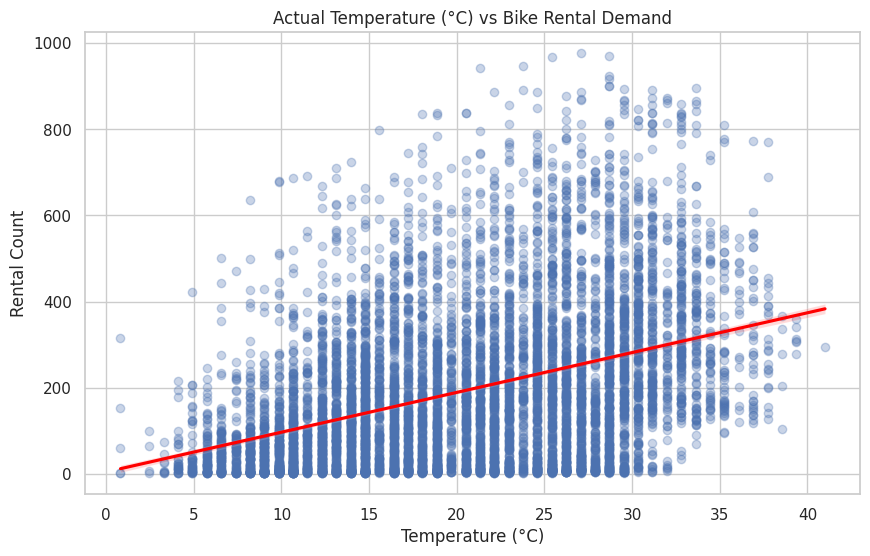

In [77]:
plt.figure(figsize=(10, 6))
sns.regplot(data=train_df, x='temp', y='count', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual Temperature (°C) vs Bike Rental Demand')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rental Count')
plt.show()

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate regression evaluation metrics

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("Model Evaluation Results")
print("=" * 40)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Evaluation Results
Mean Absolute Error (MAE): 107.81
Mean Squared Error (MSE): 20538.7
Root Mean Squared Error (RMSE): 143.31
R² Score: 0.3838


In [79]:
# evaluate model
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Model Performance")
print("------------------")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Performance
------------------
MAE: 107.81
RMSE: 143.31
R² Score: 0.3838


In [80]:
# testing scenario
new_data = pd.DataFrame({
    'year': [2012],
    'hour': [17],
    'season': [3],
    'holiday': [0],
    'workingday': [1],
    'weather': [1],
    'temp': [25],
    'atemp': [28],
    'humidity': [60],
    'windspeed': [10]
})

prediction = model.predict(new_data)[0]

print("Predicted Bike Demand:", round(max(0, prediction)))

Predicted Bike Demand: 317


In [81]:
# train final model
final_X = train_df.drop(['count', 'id'], axis=1)
final_y = train_df['count']

final_model = LinearRegression()

final_model.fit(final_X, final_y)

print("Final model trained successfully!")

Final model trained successfully!


In [82]:
# remove id column
test_X = test_df.drop(['Unnamed: 0'], axis=1)

print("Test data prepared successfully.")
print(test_X.head())

Test data prepared successfully.
   year  hour  season  holiday  workingday  weather   temp   atemp  humidity  \
0  2012    21       3        0           0        1  29.52  34.850        79   
1  2012     3       2        0           0        1  23.78  27.275        83   
2  2011    10       1        0           1        3  16.40  20.455         0   
3  2012    19       1        0           1        1  13.94  15.150        46   
4  2011    23       3        0           1        2  26.24  30.305        73   

   windspeed  
0     6.0032  
1     0.0000  
2    11.0014  
3    19.9995  
4    11.0014  


In [83]:
test_predictions = final_model.predict(test_X)

test_predictions = np.maximum(test_predictions, 0)

print("Predictions generated for test data.")
print(test_predictions[:10])

Predictions generated for test data.
[346.11103231 126.16966055 207.44337419 247.65654789 266.57676226
 162.21651445 111.20913093  93.12454306 220.67512044 147.74845631]


In [84]:
# prediction results
prediction_results = test_df.copy()

prediction_results['Predicted Count'] = np.round(test_predictions).astype(int)

prediction_results.head(10)

,Unnamed: 0,year,hour,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,Predicted Count
0,1,2012,21,3,0,0,1,29.52,34.850,79,6.0032,346
1,2,2012,3,2,0,0,1,23.78,27.275,83,0.0000,126
2,6,2011,10,1,0,1,3,16.40,20.455,0,11.0014,207
3,14,2012,19,1,0,1,1,13.94,15.150,46,19.9995,248
4,17,2011,23,3,0,1,2,26.24,30.305,73,11.0014,267
5,20,2012,6,2,0,0,1,21.32,25.000,72,7.0015,162
6,28,2012,9,4,0,0,2,10.66,12.120,93,16.9979,111
7,29,2012,9,1,0,1,2,9.84,12.880,70,11.0014,93
8,30,2011,17,4,0,1,1,13.12,14.395,42,26.0027,221
9,32,2012,12,1,0,1,2,10.66,13.635,56,7.0015,148


In [85]:
prediction_results.to_csv(
    '/content/bike_rental_predictions.csv',
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [86]:
!pip install -q gradio

In [87]:
def predict_bike_demand(
    year,
    hour,
    season,
    holiday,
    workingday,
    weather,
    temperature,
    feels_like,
    humidity,
    windspeed
):

    input_data = pd.DataFrame({
        'year': [year],
        'hour': [hour],
        'season': [season],
        'holiday': [holiday],
        'workingday': [workingday],
        'weather': [weather],
        'temp': [temperature],
        'atemp': [feels_like],
        'humidity': [humidity],
        'windspeed': [windspeed]
    })

    prediction = final_model.predict(input_data)[0]

    prediction = max(0, prediction)

    return round(prediction)

In [88]:
# Test the final model directly

test_input = pd.DataFrame({
    'year': [2012],
    'hour': [17],
    'season': [3],
    'holiday': [0],
    'workingday': [1],
    'weather': [1],
    'temp': [25],
    'atemp': [28],
    'humidity': [60],
    'windspeed': [10]
})

print("Input:")
display(test_input)

prediction = final_model.predict(test_input)

print("\nRaw Prediction:", prediction[0])
print("Rounded Prediction:", round(prediction[0]))

Input:


,year,hour,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2012,17,3,0,1,1,25,28,60,10



Raw Prediction: 318.60719537278055
Rounded Prediction: 319


In [89]:
# build UI
import gradio as gr

demo = gr.Interface(
    fn=predict_bike_demand,

    inputs=[
        gr.Dropdown(
            choices=[2011, 2012],
            value=2012,
            label="Year"
        ),

        gr.Slider(
            minimum=0,
            maximum=23,
            step=1,
            value=17,
            label="Hour"
        ),

        gr.Dropdown(
            choices=[1, 2, 3, 4],
            value=3,
            label="Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)"
        ),

        gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Holiday (0=No, 1=Yes)"
        ),

        gr.Dropdown(
            choices=[0, 1],
            value=1,
            label="Working Day (0=No, 1=Yes)"
        ),

        gr.Dropdown(
            choices=[1, 2, 3, 4],
            value=1,
            label="Weather (1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain)"
        ),

        gr.Number(
            value=25,
            label="Temperature (°C)"
        ),

        gr.Number(
            value=28,
            label="Feels-like Temperature (°C)"
        ),

        gr.Number(
            value=60,
            label="Humidity"
        ),

        gr.Number(
            value=10,
            label="Windspeed"
        )
    ],

    outputs=gr.Number(
        label="Predicted Bike Rental Demand"
    ),

    title="🚲 Bike Rental Demand Prediction",

    description="Enter weather and time conditions to predict the expected number of bike rentals."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://26a149cafc936d346e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
